In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
np.random.seed(42)

n = 300

df = pd.DataFrame({
    "Age": np.random.randint(18, 31, n),
    "Daily_Social_Media_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Sleep_Hours": np.round(np.random.uniform(4, 9, n), 1),
    "Social_Comparison": np.random.randint(1, 11, n),
    "Cyberbullying": np.random.randint(1, 11, n),
    "Academic_Stress": np.random.randint(1, 11, n),
    "Physical_Activity_Hours": np.round(np.random.uniform(0, 6, n), 1)
})

print("Dataset created successfully!")
print("Number of rows:", len(df))

df.head()

Dataset created successfully!
Number of rows: 300


,Age,Daily_Social_Media_Hours,Sleep_Hours,Social_Comparison,Cyberbullying,Academic_Stress,Physical_Activity_Hours
0,24,3.1,5.9,10,6,8,5.7
1,21,2.6,7.7,8,8,5,5.1
2,30,9.8,8.6,6,9,2,5.5
3,28,5.6,8.8,6,2,2,4.9
4,25,3.3,4.3,8,9,6,0.7


In [4]:
impact_score = (
    df["Daily_Social_Media_Hours"] * 1.5
    + df["Social_Comparison"] * 1.2
    + df["Cyberbullying"] * 1.3
    + df["Academic_Stress"] * 1.0
    - df["Sleep_Hours"] * 1.2
    - df["Physical_Activity_Hours"] * 0.5
)

df["Mental_Health_Impact"] = pd.cut(
    impact_score,
    bins=[-np.inf, 18, 32, np.inf],
    labels=["Low", "Moderate", "High"]
)

print(df["Mental_Health_Impact"].value_counts())

Mental_Health_Impact
Low         143
Moderate    142
High         15
Name: count, dtype: int64


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Records:")
print(df.head())

Dataset Shape: (300, 8)

Column Names:
['Age', 'Daily_Social_Media_Hours', 'Sleep_Hours', 'Social_Comparison', 'Cyberbullying', 'Academic_Stress', 'Physical_Activity_Hours', 'Mental_Health_Impact']

Missing Values:
Age                         0
Daily_Social_Media_Hours    0
Sleep_Hours                 0
Social_Comparison           0
Cyberbullying               0
Academic_Stress             0
Physical_Activity_Hours     0
Mental_Health_Impact        0
dtype: int64

First 5 Records:
   Age  Daily_Social_Media_Hours  Sleep_Hours  Social_Comparison  \
0   24                       3.1          5.9                 10   
1   21                       2.6          7.7                  8   
2   30                       9.8          8.6                  6   
3   28                       5.6          8.8                  6   
4   25                       3.3          4.3                  8   

   Cyberbullying  Academic_Stress  Physical_Activity_Hours  \
0              6                8          

In [6]:
print(df.describe())

              Age  Daily_Social_Media_Hours  Sleep_Hours  Social_Comparison  \
count  300.000000                300.000000   300.000000         300.000000   
mean    24.086667                  5.607667     6.527333           5.436667   
std      3.753147                  2.606509     1.388216           2.906455   
min     18.000000                  1.000000     4.000000           1.000000   
25%     21.000000                  3.300000     5.400000           3.000000   
50%     24.000000                  5.500000     6.700000           6.000000   
75%     27.000000                  7.700000     7.700000           8.000000   
max     30.000000                 10.000000     9.000000          10.000000   

       Cyberbullying  Academic_Stress  Physical_Activity_Hours  
count     300.000000       300.000000               300.000000  
mean        5.523333         5.443333                 2.923333  
std         2.942502         2.949994                 1.667791  
min         1.000000        

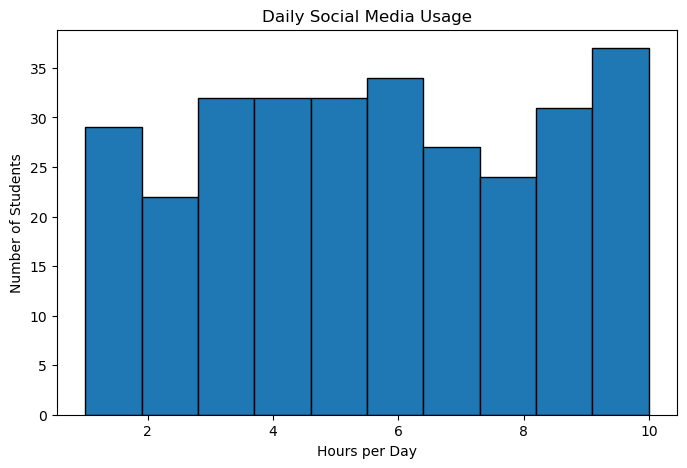

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Daily_Social_Media_Hours"],
    bins=10,
    edgecolor="black"
)

plt.title("Daily Social Media Usage")
plt.xlabel("Hours per Day")
plt.ylabel("Number of Students")

plt.show()

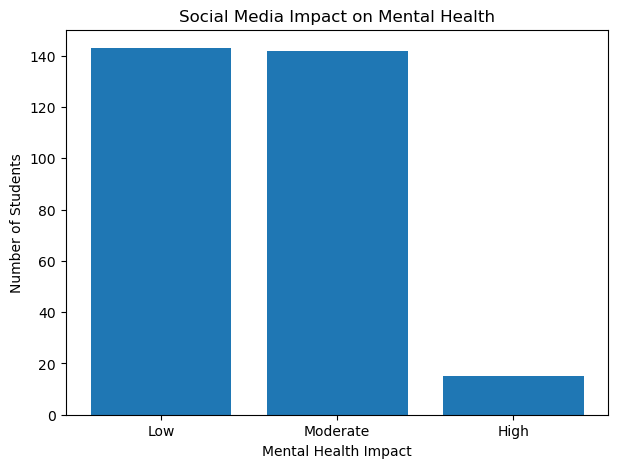

In [8]:
impact_counts = df["Mental_Health_Impact"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    impact_counts.index.astype(str),
    impact_counts.values
)

plt.title("Social Media Impact on Mental Health")
plt.xlabel("Mental Health Impact")
plt.ylabel("Number of Students")

plt.show()

In [9]:
X = df[
    [
        "Age",
        "Daily_Social_Media_Hours",
        "Sleep_Hours",
        "Social_Comparison",
        "Cyberbullying",
        "Academic_Stress",
        "Physical_Activity_Hours"
    ]
]

y = df["Mental_Health_Impact"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input Features:
['Age', 'Daily_Social_Media_Hours', 'Sleep_Hours', 'Social_Comparison', 'Cyberbullying', 'Academic_Stress', 'Physical_Activity_Hours']

Target:
Mental_Health_Impact


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 240
Testing samples: 60


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed successfully!")

Data scaling completed successfully!


In [12]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed successfully!")
print(y_pred[:10])

Predictions completed successfully!
['Low' 'High' 'Moderate' 'Low' 'Low' 'High' 'Low' 'Low' 'Moderate' 'Low']


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 95.0 %


In [15]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       0.97      0.97      0.97        29
    Moderate       0.96      0.93      0.95        28

    accuracy                           0.95        60
   macro avg       0.89      0.96      0.92        60
weighted avg       0.95      0.95      0.95        60



Confusion Matrix:
[[28  1  0]
 [ 1 26  1]
 [ 0  0  3]]


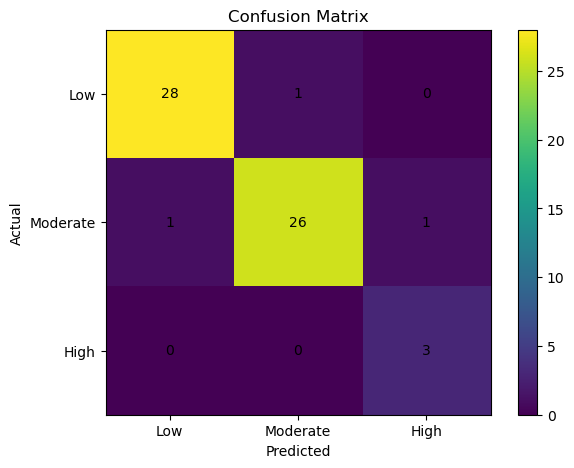

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Moderate", "High"]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(3),
    ["Low", "Moderate", "High"]
)

plt.yticks(
    range(3),
    ["Low", "Moderate", "High"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(model.coef_).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Important Factors:")
print(importance)

Important Factors:
                    Feature  Importance
4             Cyberbullying    1.730028
1  Daily_Social_Media_Hours    1.558814
3         Social_Comparison    1.339731
5           Academic_Stress    1.119644
2               Sleep_Hours    0.653624
6   Physical_Activity_Hours    0.490192
0                       Age    0.132962


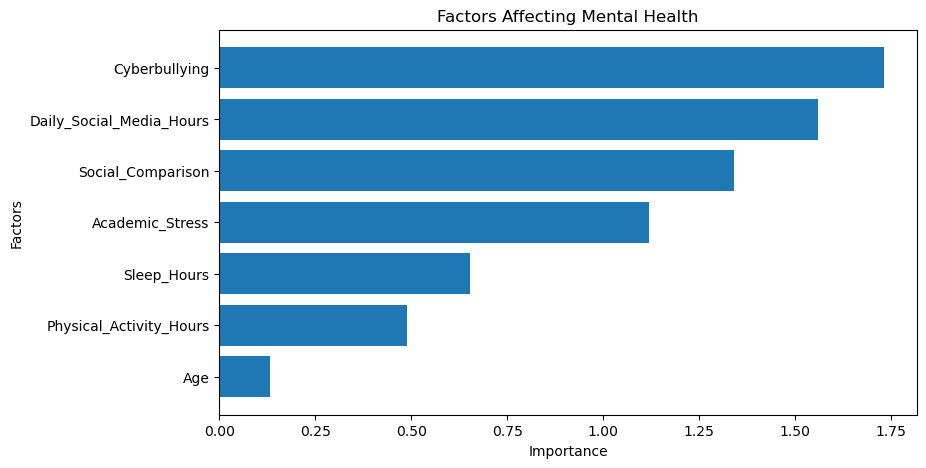

In [18]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Factors Affecting Mental Health")
plt.xlabel("Importance")
plt.ylabel("Factors")

plt.gca().invert_yaxis()

plt.show()

In [19]:
new_student = pd.DataFrame({
    "Age": [20],
    "Daily_Social_Media_Hours": [7],
    "Sleep_Hours": [5],
    "Social_Comparison": [8],
    "Cyberbullying": [4],
    "Academic_Stress": [7],
    "Physical_Activity_Hours": [1]
})

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

print("Predicted Mental Health Impact:", prediction[0])

Predicted Mental Health Impact: Moderate


In [20]:
print("==========================================")
print(" SOCIAL MEDIA IMPACT ON MENTAL HEALTH")
print("==========================================")
print("Machine Learning Model : Logistic Regression")
print("Dataset Size           :", len(df))
print("Model Accuracy         :", round(accuracy * 100, 2), "%")
print("==========================================")

print("\nConclusion:")
print(
    "The project analyzes social media usage and related factors "
    "such as sleep, social comparison, cyberbullying and academic stress. "
    "The machine learning model classifies the possible impact level "
    "as Low, Moderate, or High."
)

 SOCIAL MEDIA IMPACT ON MENTAL HEALTH
Machine Learning Model : Logistic Regression
Dataset Size           : 300
Model Accuracy         : 95.0 %

Conclusion:
The project analyzes social media usage and related factors such as sleep, social comparison, cyberbullying and academic stress. The machine learning model classifies the possible impact level as Low, Moderate, or High.


In [21]:
print("==========================================")
print(" SOCIAL MEDIA IMPACT ON MENTAL HEALTH")
print("==========================================")
print("Machine Learning Model : Logistic Regression")
print("Dataset Size           :", len(df))
print("Model Accuracy         :", round(accuracy * 100, 2), "%")
print("==========================================")

print("\nConclusion:")
print(
    "The project analyzes social media usage and related factors "
    "such as sleep, social comparison, cyberbullying and academic stress. "
    "The machine learning model classifies the possible impact level "
    "as Low, Moderate, or High."
)

 SOCIAL MEDIA IMPACT ON MENTAL HEALTH
Machine Learning Model : Logistic Regression
Dataset Size           : 300
Model Accuracy         : 95.0 %

Conclusion:
The project analyzes social media usage and related factors such as sleep, social comparison, cyberbullying and academic stress. The machine learning model classifies the possible impact level as Low, Moderate, or High.
